# 08 — Decoding Parameters: Temperature, Top-p, Top-k

A prompt engineering és a decoding nem ugyanaz. Itt a promptot fixen tartjuk, és **egy sampling paramétert változtatunk egyszerre**.

In [1]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "02_notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
print("Project root:", PROJECT_ROOT)

Project root: <PROJECT_ROOT>


In [2]:
from prompt_benchmark.llm.factory import PROVIDER_CAPABILITIES
pd.DataFrame(PROVIDER_CAPABILITIES).T

,temperature,top_p,top_k,structured_output,reasoning_effort
mock,True,True,True,True,False
ollama,True,True,True,True,False
groq,True,True,False,True,True
gemini,True,True,True,True,True
openai,True,True,False,True,True


## Temperature
Nagyobb érték → nagyobb variancia. Klasszifikációhoz tipikusan alacsony érték indokolt.

## Top-p
Nucleus sampling: a kumulatív valószínűségi tömeg alapján korlátozza a tokenjelölteket.

## Top-k
Legfeljebb a K legvalószínűbb token marad. Nem minden provider API támogatja.

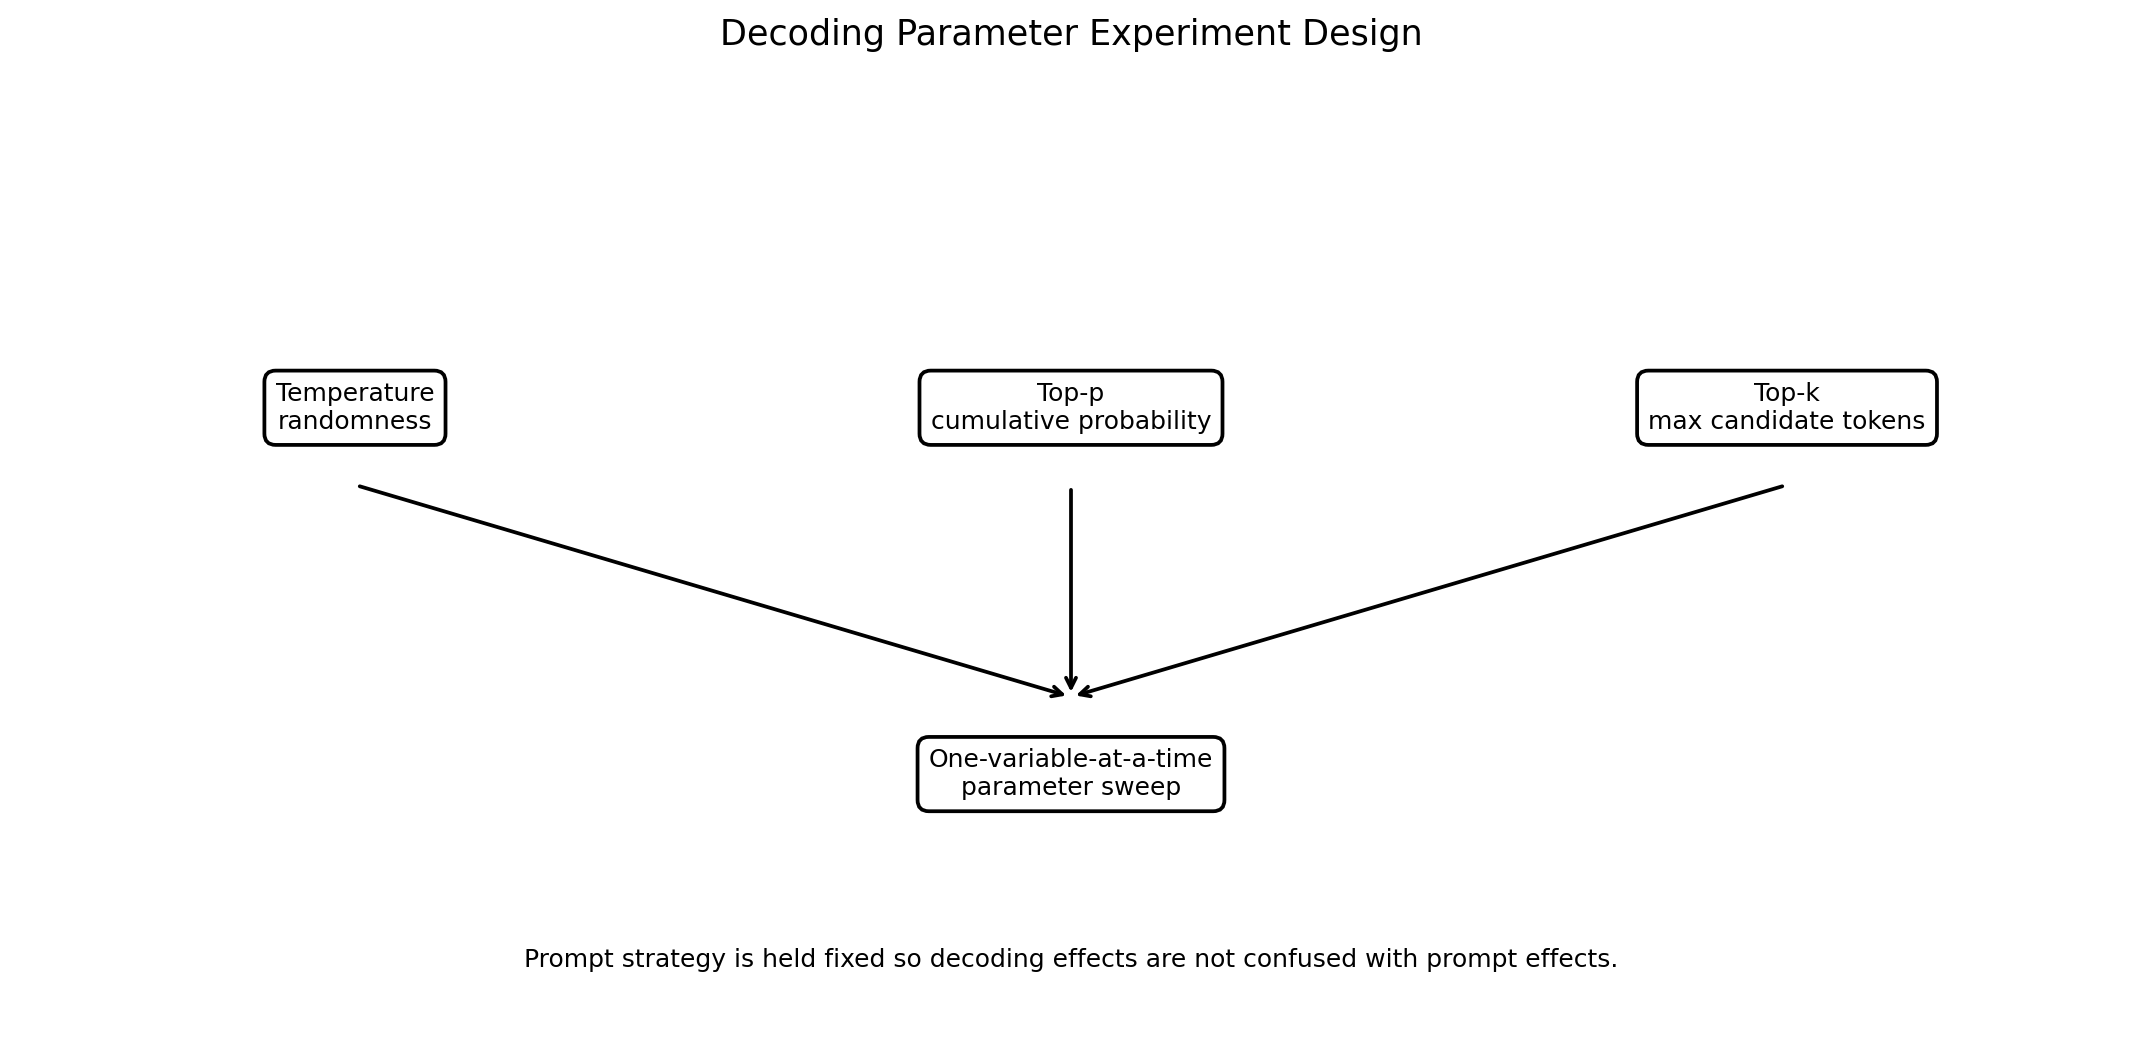

In [3]:
from IPython.display import Image, display
path=PROJECT_ROOT/"07_outputs/reports/figures/00g_decoding_parameters.png"
if path.exists(): display(Image(filename=str(path)))

## Miért one-variable-at-a-time?
Ha egyszerre módosítjuk a temperature-t, top_p-t és a promptot, a teljesítményváltozás oka nem azonosítható. Ez klasszikus confounding.

In [4]:
sweep_path=PROJECT_ROOT/"07_outputs/results/parameter_sweeps/mock/parameter_sweep_summary.csv"
if sweep_path.exists():
    sweep=pd.read_csv(sweep_path)
    display(sweep[["parameter","value","macro_f1","invalid_output_rate","mean_total_tokens","p95_latency_seconds"]])
else:
    print("Run: python 05_scripts/06_run_parameter_sweep.py --provider mock --force")

,parameter,value,macro_f1,invalid_output_rate,mean_total_tokens,p95_latency_seconds
0,temperature,0.00,0.916334,0.0,1608.933333,1.08505
1,temperature,0.20,0.916334,0.0,1608.933333,1.08505
2,temperature,0.50,0.897904,0.0,1608.933333,1.08505
3,temperature,0.80,0.855840,0.0,1608.933333,1.08505
4,top_p,0.50,0.855840,0.0,1608.933333,1.08505
5,top_p,0.80,0.916334,0.0,1608.933333,1.08505
6,top_p,0.95,0.916334,0.0,1608.933333,1.08505
7,top_p,1.00,0.916334,0.0,1608.933333,1.08505
8,top_k,10.00,0.877915,0.0,1608.933333,1.08505
9,top_k,20.00,0.916334,0.0,1608.933333,1.08505


### Mock értelmezés
A mock classifier determinisztikus, ezért a temperature/top_p/top_k nem változtatja a predikcióját. Ez **helyes pipeline-demó**, de nem decoding research result. Valódi hatást Ollama/Groq/Gemini/OpenAI modellen mérj.